In [1]:
# 데이터 가져오기
# drive에 연결
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
# 현재 데이터가 있는 공간으로 작업 경로를 변경
%cd "/content/drive/MyDrive/Colab Notebooks"


Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks


In [2]:
# pandas 패키지 별칭 pd라는 별칭으로 불러오기
import pandas as pd

# sample_submission.csv 파일을 submission 이라는 변수에 할당
submission = pd.read_csv("sample_submission.csv")  # 제출파일

# pandas 내에 있는 read_csv 함수를 사용해
# train.csv , test.csv 파일을 각각 train , test 라는 이름으로 불러오기
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')


In [3]:
submission.head()  # 0 , 1 , 2 다중클래스 잘되었는지 확인


,index,0,1,2
0,26457,0,0,0
1,26458,0,0,0
2,26459,0,0,0
3,26460,0,0,0
4,26461,0,0,0


In [4]:
# train 데이터 하위 행 5개 확인
train.tail()


,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
26452,26452,F,N,N,2,225000.0,State servant,Secondary / secondary special,Married,House / apartment,-12079,-1984,1,0,0,0,Core staff,4.0,-2.0,1.0
26453,26453,F,N,Y,1,180000.0,Working,Higher education,Separated,House / apartment,-15291,-2475,1,0,0,0,NaN,2.0,-47.0,2.0
26454,26454,F,Y,N,0,292500.0,Working,Secondary / secondary special,Civil marriage,With parents,-10082,-2015,1,0,0,0,Core staff,2.0,-25.0,2.0
26455,26455,M,N,Y,0,171000.0,Working,Incomplete higher,Single / not married,House / apartment,-10145,-107,1,0,0,0,Laborers,1.0,-59.0,2.0
26456,26456,F,N,N,0,81000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-19569,-1013,1,0,0,0,Security staff,2.0,-9.0,2.0


In [5]:
# train 데이터들의 컬럼 확인 , feature 확인
train.columns


Index(['index', 'gender', 'car', 'reality', 'child_num', 'income_total',
       'income_type', 'edu_type', 'family_type', 'house_type', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'work_phone', 'phone', 'email',
       'occyp_type', 'family_size', 'begin_month', 'credit'],
      dtype='object')

In [6]:
# train 데이터의 행과 열의 개수 확인
train.shape


(26457, 20)

In [7]:
# train 데이터프레임의 정보 확인, 데이터 분포를 봐야함. 무작정 코드 실행하면 안됨.
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26457 entries, 0 to 26456
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          26457 non-null  int64  
 1   gender         26457 non-null  object 
 2   car            26457 non-null  object 
 3   reality        26457 non-null  object 
 4   child_num      26457 non-null  int64  
 5   income_total   26457 non-null  float64
 6   income_type    26457 non-null  object 
 7   edu_type       26457 non-null  object 
 8   family_type    26457 non-null  object 
 9   house_type     26457 non-null  object 
 10  DAYS_BIRTH     26457 non-null  int64  
 11  DAYS_EMPLOYED  26457 non-null  int64  
 12  FLAG_MOBIL     26457 non-null  int64  
 13  work_phone     26457 non-null  int64  
 14  phone          26457 non-null  int64  
 15  email          26457 non-null  int64  
 16  occyp_type     18286 non-null  object 
 17  family_size    26457 non-null  float64
 18  begin_

In [8]:
# train 데이터의 기초 통계량을 간략하게 확인(개수, 표준편차 등)
train.describe()


,index,child_num,income_total,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,family_size,begin_month,credit
count,26457.000000,26457.000000,2.645700e+04,26457.000000,26457.000000,26457.0,26457.000000,26457.000000,26457.000000,26457.000000,26457.000000,26457.000000
mean,13228.000000,0.428658,1.873065e+05,-15958.053899,59068.750728,1.0,0.224742,0.294251,0.091280,2.196848,-26.123294,1.519560
std,7637.622372,0.747326,1.018784e+05,4201.589022,137475.427503,0.0,0.417420,0.455714,0.288013,0.916717,16.559550,0.702283
min,0.000000,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000,-60.000000,0.000000
25%,6614.000000,0.000000,1.215000e+05,-19431.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,2.000000,-39.000000,1.000000
50%,13228.000000,0.000000,1.575000e+05,-15547.000000,-1539.000000,1.0,0.000000,0.000000,0.000000,2.000000,-24.000000,2.000000
75%,19842.000000,1.000000,2.250000e+05,-12446.000000,-407.000000,1.0,0.000000,1.000000,0.000000,3.000000,-12.000000,2.000000
max,26456.000000,19.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000,0.000000,2.000000


In [9]:
# 각 변수들을 날짜 단위가 아닌 연 단위 (만 나이)로 바꿔보기(begin_month 제외)
train.loc[train["DAYS_EMPLOYED"] > 0, "DAYS_EMPLOYED"] = 0  # 0 보다 큰경우 0
train["DAYS_BIRTH"]    = (train["DAYS_BIRTH"]    * -1) / 365.0
train["DAYS_EMPLOYED"] = (train["DAYS_EMPLOYED"] * -1) / 365.0
train["begin_month"]   =  train["begin_month"]   * -1

# 동일하게 해줘야 함
test.loc[test["DAYS_EMPLOYED"] > 0, "DAYS_EMPLOYED"] = 0
test["DAYS_BIRTH"]    = (test["DAYS_BIRTH"]    * -1) / 365.0
test["DAYS_EMPLOYED"] = (test["DAYS_EMPLOYED"] * -1) / 365.0
test["begin_month"]   =  test["begin_month"]   * -1


In [10]:
# train 데이터의 카테고리 컬럼들을 추출
categories = train.select_dtypes(exclude='number')

# 추출한 변수들의 값들의 비율을 확인
for feature in categories:  # 모든 피처에 대해서
    print(train[feature].value_counts(normalize=True))
    # 직업, 거주타입 ,결혼여부, 차 소유, 카드 발급여부 등
    # 결측치 있는데 데이터있음
    print('-' * 50)


gender
F    0.668897
M    0.331103
Name: proportion, dtype: float64
--------------------------------------------------
car
N    0.620252
Y    0.379748
Name: proportion, dtype: float64
--------------------------------------------------
reality
Y    0.673924
N    0.326076
Name: proportion, dtype: float64
--------------------------------------------------
income_type
Working                 0.515743
Commercial associate    0.234418
Pensioner               0.168160
State servant           0.081415
Student                 0.000265
Name: proportion, dtype: float64
--------------------------------------------------
edu_type
Secondary / secondary special    0.680160
Higher education                 0.270703
Incomplete higher                0.038553
Lower secondary                  0.009714
Academic degree                  0.000869
Name: proportion, dtype: float64
--------------------------------------------------
family_type
Married                 0.687757
Single / not married    0.132139
Civ

In [11]:
# train 데이터의 'occyp_type' 변수의 결측치들을 "No job"으로 채우기
train["occyp_type"] = train["occyp_type"].fillna("No job")
test["occyp_type"]  = test["occyp_type"].fillna("No job")

occyp_order = train['occyp_type'].value_counts().sort_values(ascending=False).index.tolist()

train.to_csv("train_processed.csv", index=False)

# occyp_type 변수의 값의 비율을 백분율로 확인  # 결측치 No job 30.88
round(train["occyp_type"].value_counts(normalize=True) * 100, 2)


,proportion
occyp_type,
No job,30.88
Laborers,17.05
Core staff,10.00
Sales staff,9.60
Managers,8.19
Drivers,5.95
High skill tech staff,3.93
Accountants,3.41
Medicine staff,3.27


In [12]:
# 모델링
# credit 변수 돌리기
# 신용등급 2, 1, 0
train["credit"].value_counts()


,count
credit,
2.0,16968
1.0,6267
0.0,3222


In [13]:
# 전처리된 train, test 데이터를 각각 저장해주기
# x: 독립변수(원인) y: 종속변수(결과)
train.to_csv("train_processed.csv", index=False)
test.to_csv("test_processed.csv",   index=False)


In [14]:
from sklearn.tree import DecisionTreeClassifier  # 지니불순도 , 가지치기 해나갈 것.

# sklearn 패키지의 tree 모듈에서 DecisionTreeClassifier 객체를 불러옴
from sklearn.tree import DecisionTreeClassifier

# model 이라는 변수에 DecisionTreeClassifier 객체를 할당
model = DecisionTreeClassifier(random_state=42)


In [15]:
print(train['occyp_type'].head())


0         No job
1       Laborers
2       Managers
3    Sales staff
4       Managers
Name: occyp_type, dtype: object


In [16]:
# sklearn 패키지의 preprocessing 모듈에서 LabelEncoder 함수를 불러오기
from sklearn.preprocessing import LabelEncoder

# le라는 변수에 LabelEncoder 인스턴스를 할당
le = LabelEncoder()

# LabelEncoder로 object 타입 변수들을 수치형 데이터로 변환
cols = train.select_dtypes(include=['object']).columns

# 전부 수치형 데이터로 바꿔주기
# ★ 수정: train fit → test transform (인코딩 불일치 방지)
for col in cols:
    le.fit(train[col])
    train[col] = le.transform(train[col])
    test[col]  = test[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
    test[col]  = le.transform(test[col])


In [17]:
# 변환결과를 확인, 문자를 찾아볼 수 없다. (정규화를 시킨다던지. 전처리 스타일)
train.head()


,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
0,0,0,0,0,0,202500.0,0,1,1,2,38.079452,12.901370,1,0,0,0,12,2.0,6.0,1.0
1,1,0,0,1,1,247500.0,0,4,0,1,31.178082,4.219178,1,0,0,1,8,3.0,5.0,1.0
2,2,1,1,1,0,450000.0,4,1,1,1,52.293151,12.147945,1,0,1,0,10,2.0,22.0,2.0
3,3,0,0,1,0,202500.0,0,4,1,1,41.336986,5.731507,1,0,1,0,15,2.0,37.0,0.0
4,4,0,1,1,0,157500.0,2,1,1,1,41.197260,5.767123,1,0,0,0,10,2.0,26.0,2.0


In [18]:
# train 데이터를 독립변수 X 와 종속변수 y로 나눠줌
X = train.drop(columns="credit")  # credit drop시킴, 원본 손상 없음
y = train["credit"]                # y에 값을 넣기

# sklearn 패키지의 train_test_split 함수를 불러옴
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# model 학습을 진행
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [20]:
from sklearn.metrics import accuracy_score  # 정확도

y_pred = model.predict(X_valid)
acc    = accuracy_score(y_valid, y_pred)
print(f"Accuracy : {round(acc, 4)}")  # 100명중 58


Accuracy : 0.5865


In [21]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_valid)
cm     = confusion_matrix(y_valid, y_pred, labels=[0, 1, 2])
print(cm)
# 혼동행렬 0 1 2 row , col 0,1,2


[[ 164  156  330]
 [ 174  521  567]
 [ 379  582 2419]]


In [22]:
pred = model.predict_proba(test)
submission.iloc[:, 1:] = pred
submission


,index,0,1,2
0,26457,0,0,1
1,26458,0,0,1
2,26459,1,0,0
3,26460,0,0,1
4,26461,0,1,0
...,...,...,...,...
9995,36452,0,0,1
9996,36453,1,0,0
9997,36454,0,1,0
9998,36455,0,1,0


In [23]:
# 1에 저장
submission.to_csv("submission1.csv", index=False)


In [24]:
# matplotlib.pyplot을 별칭 plt로 불러옴
import matplotlib.pyplot as plt

# seaborn을 별칭 sns 로 불러와
import seaborn as sns

rc = {
    "axes.facecolor":   "#F6F6F6",
    "figure.facecolor": "#B8B8B8",
    "axes.edgecolor":   "#000000",
    "grid.color":       "#C4C4C4",
    "axes.labelcolor":  "#000000",
    "xtick.color":      "#000000",
    "ytick.color":      "#000000",
    "grid.alpha":       0.4
}
sns.set(rc=rc)


<Axes: xlabel='credit', ylabel='count'>

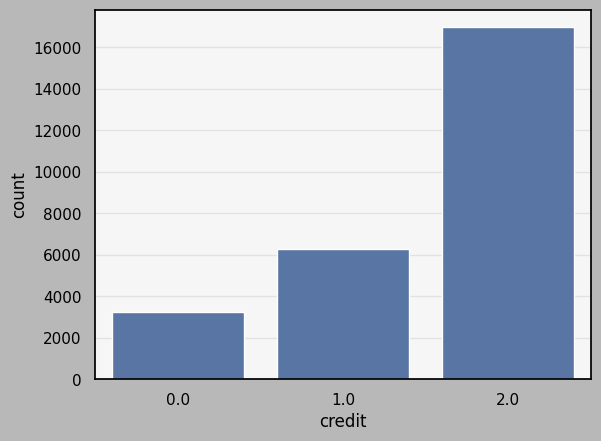

In [25]:
sns.countplot(train, x="credit")


In [26]:
print(train.dtypes)


index              int64
gender             int64
car                int64
reality            int64
child_num          int64
income_total     float64
income_type        int64
edu_type           int64
family_type        int64
house_type         int64
DAYS_BIRTH       float64
DAYS_EMPLOYED    float64
FLAG_MOBIL         int64
work_phone         int64
phone              int64
email              int64
occyp_type         int64
family_size      float64
begin_month      float64
credit           float64
dtype: object


In [27]:
# FLAG_MOBIL, work_phone, phone, email 의 타입을 바꿔줌
train['FLAG_MOBIL'] = train['FLAG_MOBIL'].astype('object')
train['work_phone'] = train['work_phone'].astype('object')
train['phone']      = train['phone'].astype('object')
train['email']      = train['email'].astype('object')

# pandas 가 csv 파일에서 타입을 자동으로 판단하는 부분을 수동으로.
# 0,1 을 int64로 읽음. 수치형이 아닌 카테고리임을 알려줌
cat_cols = ['gender', 'car', 'reality', 'income_type', 'edu_type',
            'family_type', 'house_type', 'occyp_type']
for col in cat_cols:
    train[col] = train[col].astype('object')


In [28]:
# 수치형, 카테고리 정보 넘김
train_num = train.select_dtypes(include="number").copy()
train_num["credit"] = train["credit"]

train_cat = train.select_dtypes(exclude="number").copy()
train_cat["credit"] = train["credit"]


In [29]:
train_num.describe()


,index,child_num,income_total,DAYS_BIRTH,DAYS_EMPLOYED,family_size,begin_month,credit
count,26457.000000,26457.000000,2.645700e+04,26457.000000,26457.000000,26457.000000,26457.000000,26457.000000
mean,13228.000000,0.428658,1.873065e+05,43.720696,6.023369,2.196848,26.123294,1.519560
std,7637.622372,0.747326,1.018784e+05,11.511203,6.493536,0.916717,16.559550,0.702283
min,0.000000,0.000000,2.700000e+04,21.109589,0.000000,1.000000,-0.000000,0.000000
25%,6614.000000,0.000000,1.215000e+05,34.098630,1.115068,2.000000,12.000000,1.000000
50%,13228.000000,0.000000,1.575000e+05,42.594521,4.216438,2.000000,24.000000,2.000000
75%,19842.000000,1.000000,2.250000e+05,53.235616,8.638356,3.000000,39.000000,2.000000
max,26456.000000,19.000000,1.575000e+06,68.909589,43.049315,20.000000,60.000000,2.000000


In [30]:
# Seaborn, Matplotlib → plotly 시각화 툴 변경
import plotly.express as px
from plotly.subplots import make_subplots
import math

# 1. 컬럼 개수에 따라 필요한 행(rows) 수 자동 계산
num_eda_cols = train_num.columns[:-1]
n_cols = 2
n_rows = math.ceil(len(num_eda_cols) / n_cols)  # 예: 컬럼 9개면 5행 생성

# 2. 서브플롯 틀 만들기
fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=num_eda_cols,
    vertical_spacing=0.05  # 위아래 간격 살짝 조정
)

# 색상 매핑
color_map = {0: "#FA5858", 1: "#2EFE2E", 2: "#0040FF"}

# 3. 반복문으로 그리기
for i, col in enumerate(num_eda_cols):
    r = (i // n_cols) + 1
    c = (i %  n_cols) + 1

    sub_fig = px.box(train_num, x="credit", y=col,
                     color="credit", color_discrete_map=color_map,
                     category_orders={"credit": [0, 1, 2]})

    for trace in sub_fig.data:
        trace.showlegend = (i == 0)
        fig.add_trace(trace, row=r, col=c)

# 4. 레이아웃 조정
fig.update_layout(
    height=400 * n_rows, width=1000,
    title_text="< Credit Distribution (Interactive Plotly) >",
    title_x=0.5, showlegend=True
)
fig.show()


In [31]:
print(train[['DAYS_BIRTH', 'DAYS_EMPLOYED', 'begin_month']].head())


   DAYS_BIRTH  DAYS_EMPLOYED  begin_month
0   38.079452      12.901370          6.0
1   31.178082       4.219178          5.0
2   52.293151      12.147945         22.0
3   41.336986       5.731507         37.0
4   41.197260       5.767123         26.0


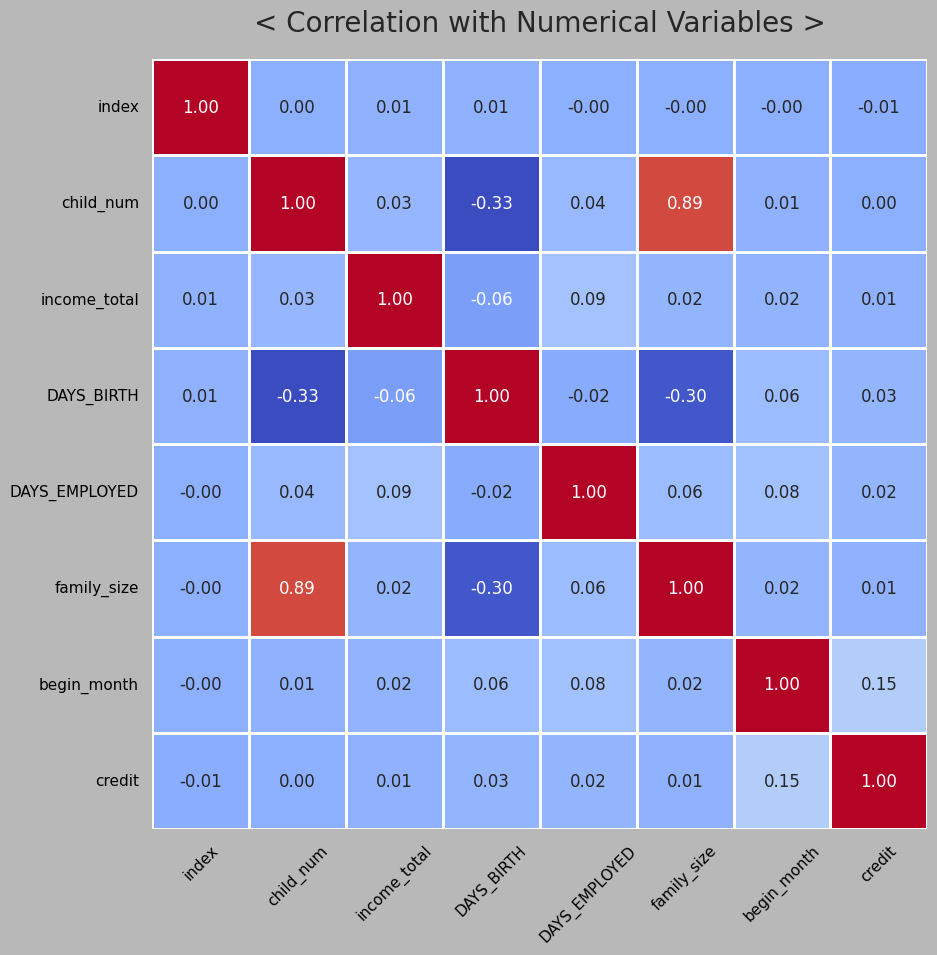

In [32]:
# 추출한 상관관계를 바탕으로 heatmap을 그리기
plt.figure(figsize=(10, 10))
sns.heatmap(train_num.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=1, cbar=False)
plt.xticks(rotation=45)
plt.title("< Correlation with Numerical Variables >", pad=20, fontsize=20)
plt.show()


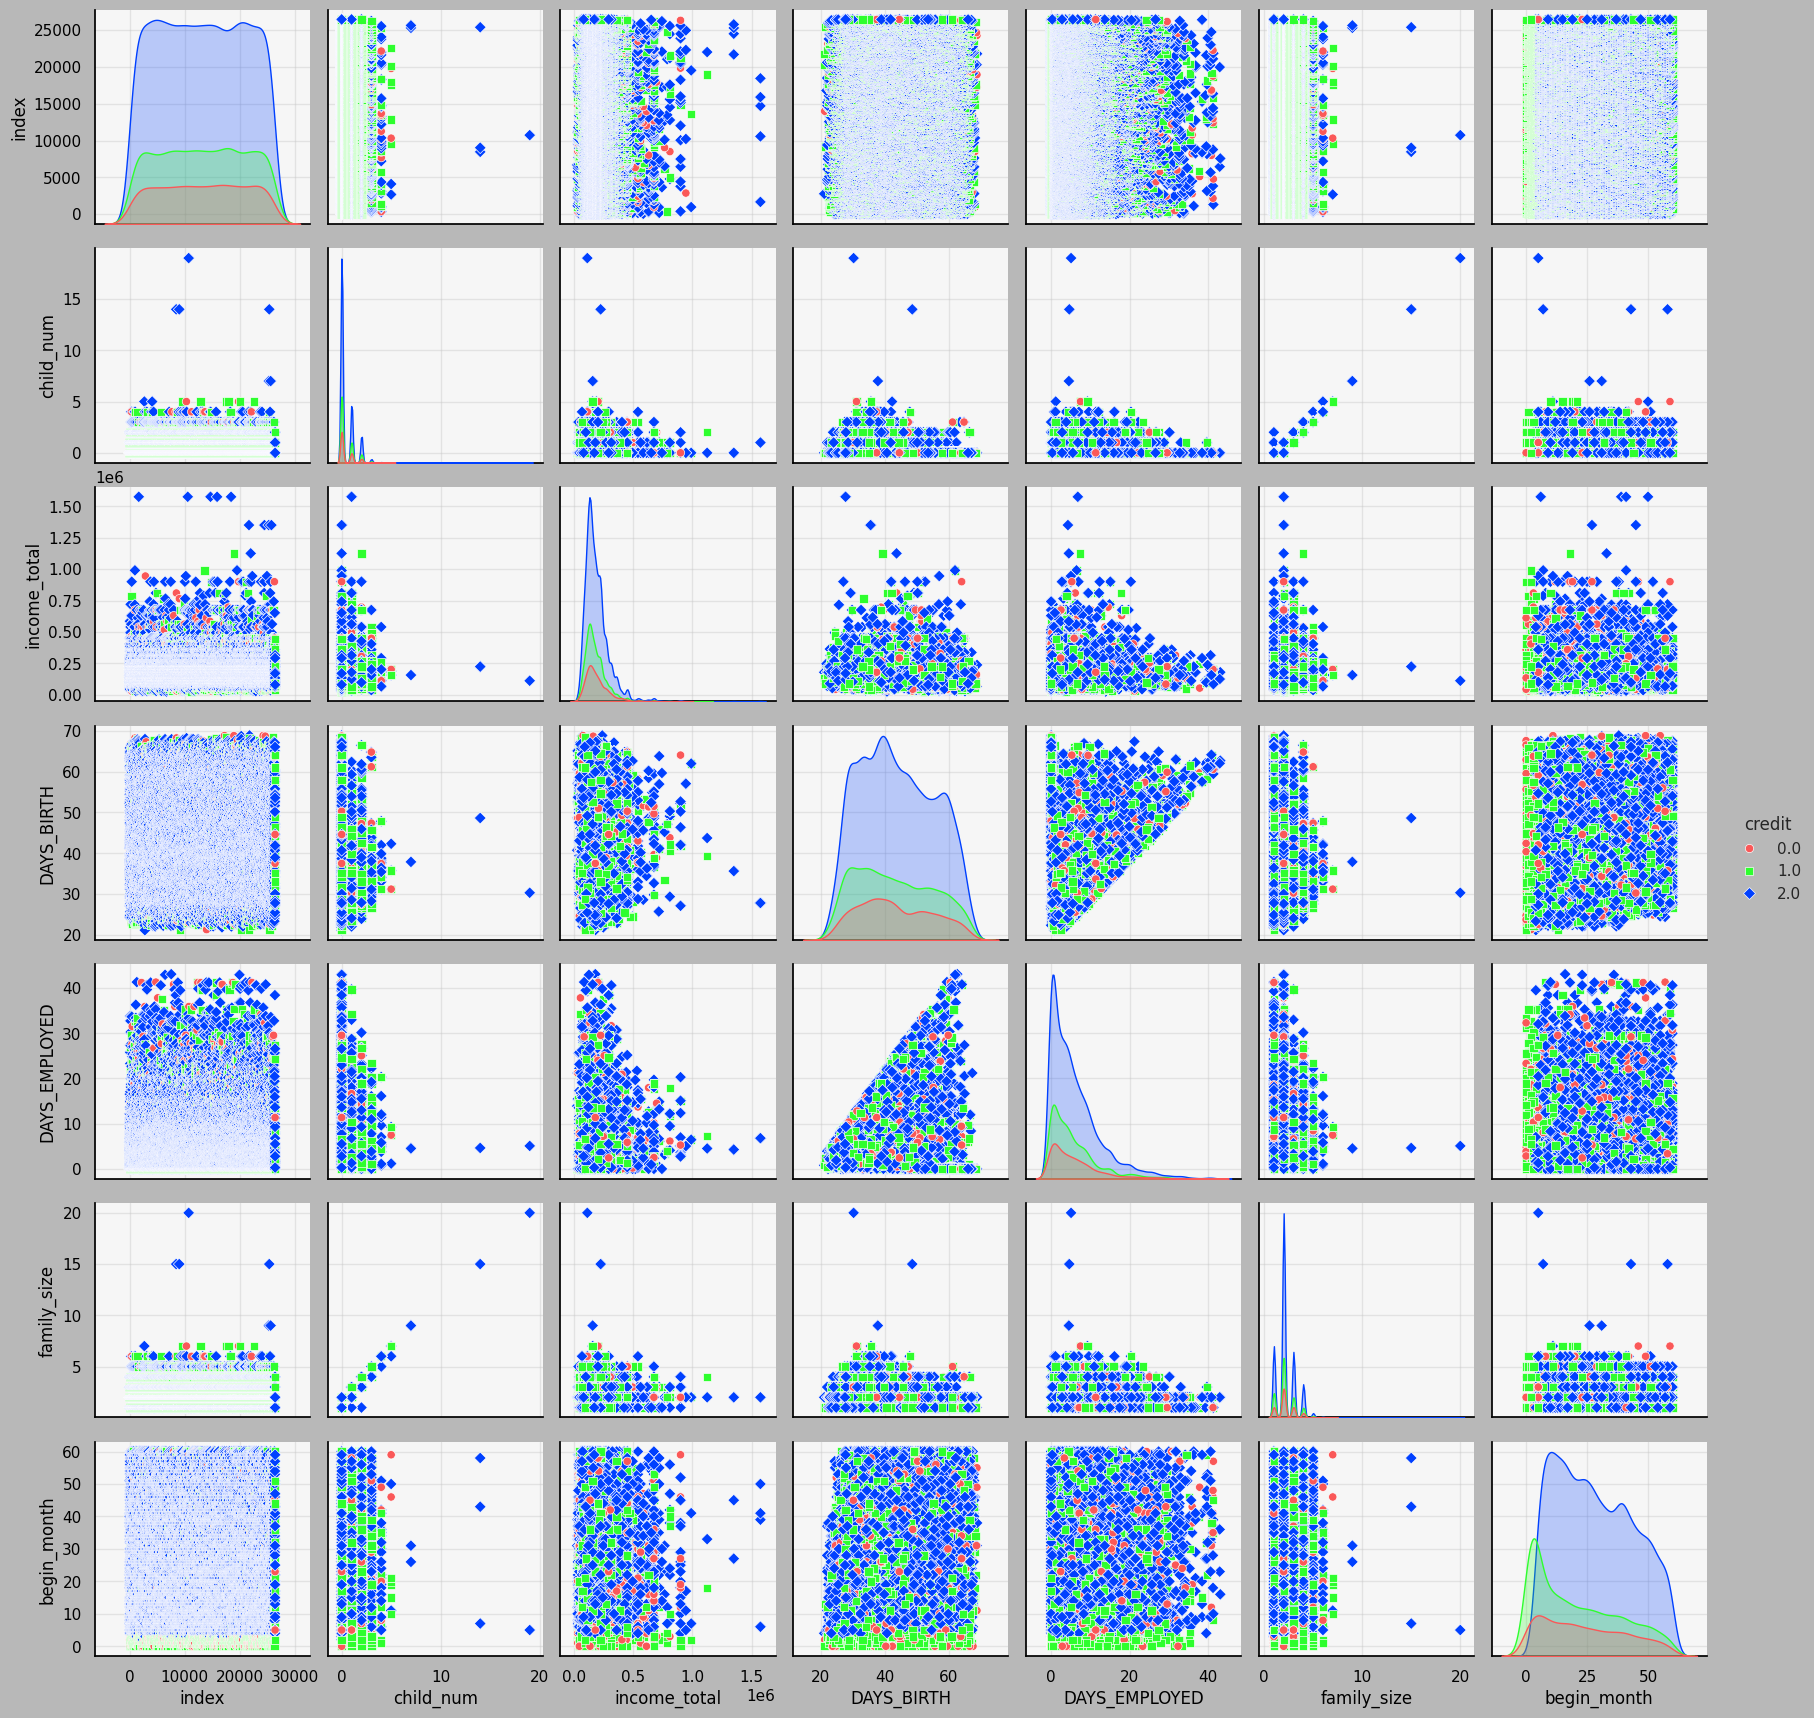

In [33]:
# train_num 데이터로 변수들 간의 상관관계를 더 자세히 확인
color = ["#FA5858", "#2EFE2E", "#0040FF"]
sns.pairplot(train_num, hue="credit", markers=["o", "s", "D"], palette=color)


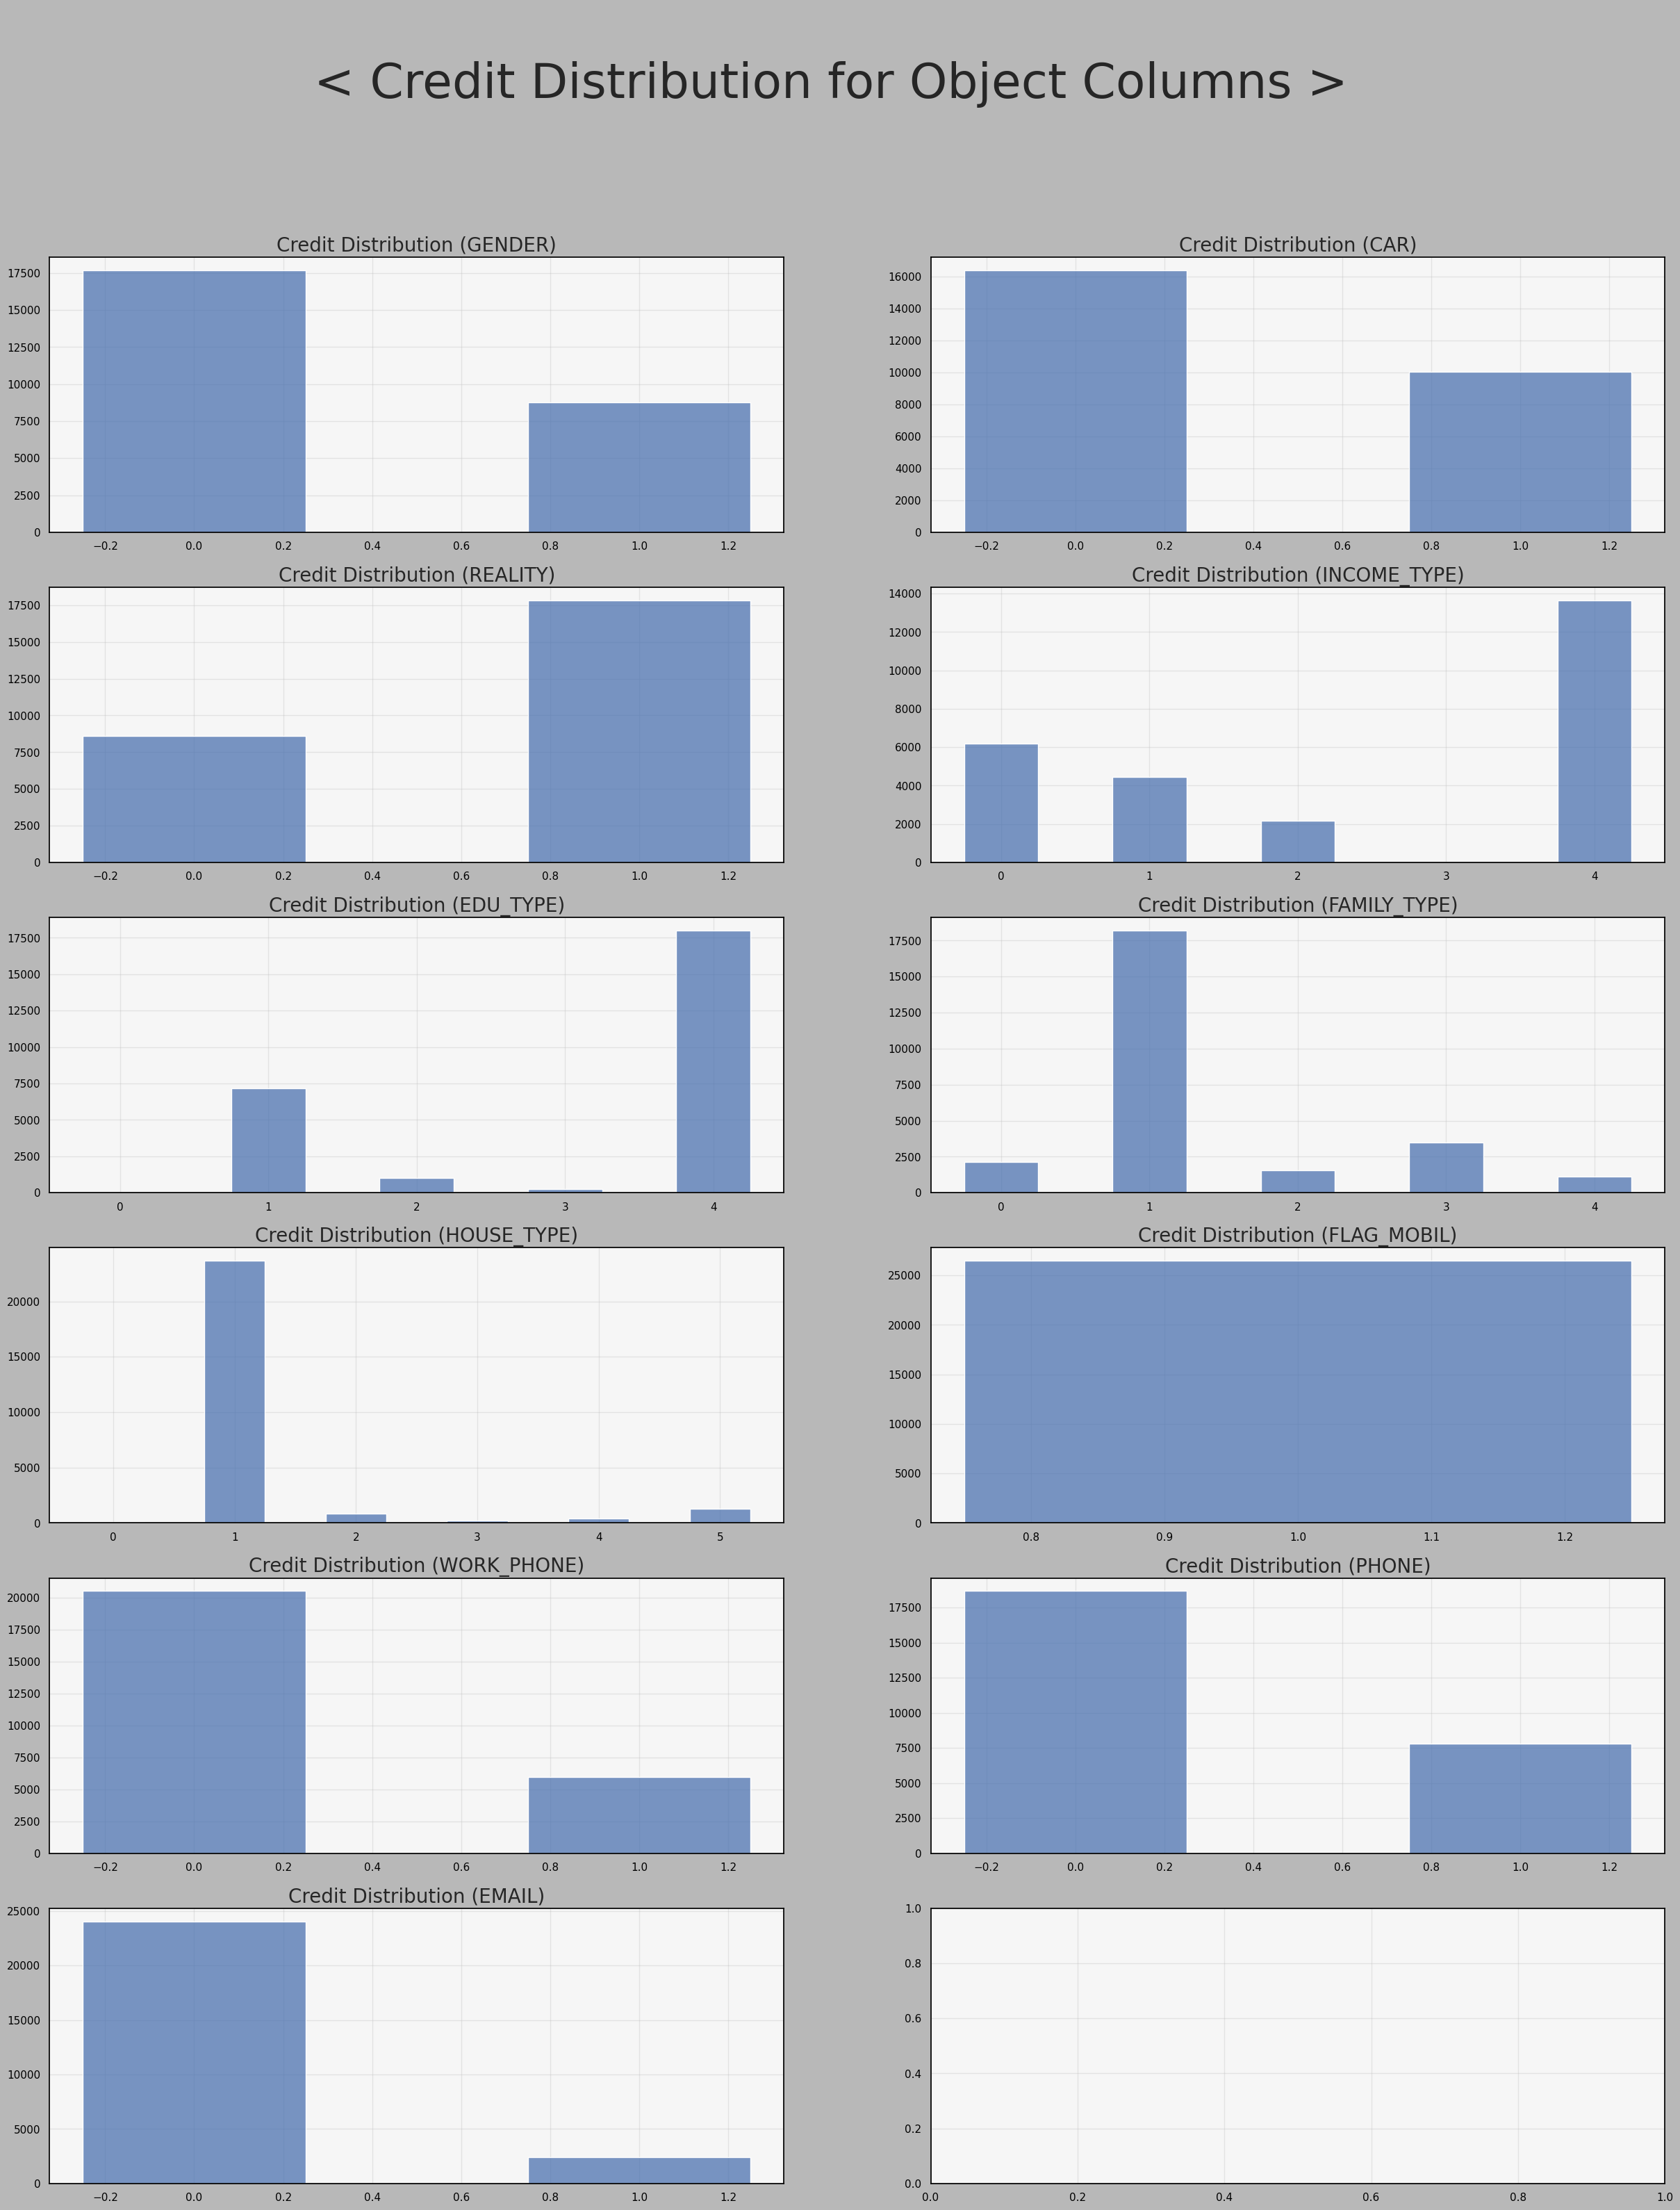

In [34]:
# category columns EDA (without 'occup_type')
cat_EDA_cols = train_cat.columns[:-2]
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(30, 36))
axes = axes.flatten()

for i, col in enumerate(cat_EDA_cols):
    ax = axes[i]
    sorted_col = train_cat[col].value_counts().sort_values(ascending=False).index
    train_cat[col] = pd.Categorical(train_cat[col], sorted_col)
    sns.histplot(data=train_cat, x=col, binwidth=0.5, shrink=0.5,
                 ax=ax, multiple="dodge")
    ax.set_title(f"Credit Distribution ({col.upper()})", fontsize=20)
    ax.set_ylabel("")
    ax.set_xlabel("")

plt.suptitle("\n< Credit Distribution for Object Columns >", fontsize=50)
plt.show()


In [35]:
# 변수 occyp_type을 내림차순으로 정리
sorted_col = train_cat["occyp_type"].value_counts().sort_values(ascending=False).index
train_cat["occyp_type"] = pd.Categorical(train_cat["occyp_type"], sorted_col)

# 이진 데이터와 나머지 데이터로 나누기
bin_cols = ["gender", "car", "reality", "FLAG_MOBIL", "work_phone", "phone", "email"]
train_cat_bin  = train_cat[bin_cols].copy()
train_cat_bin["credit"] = train_cat["credit"]
train_cat_over = train_cat.drop(columns=bin_cols)


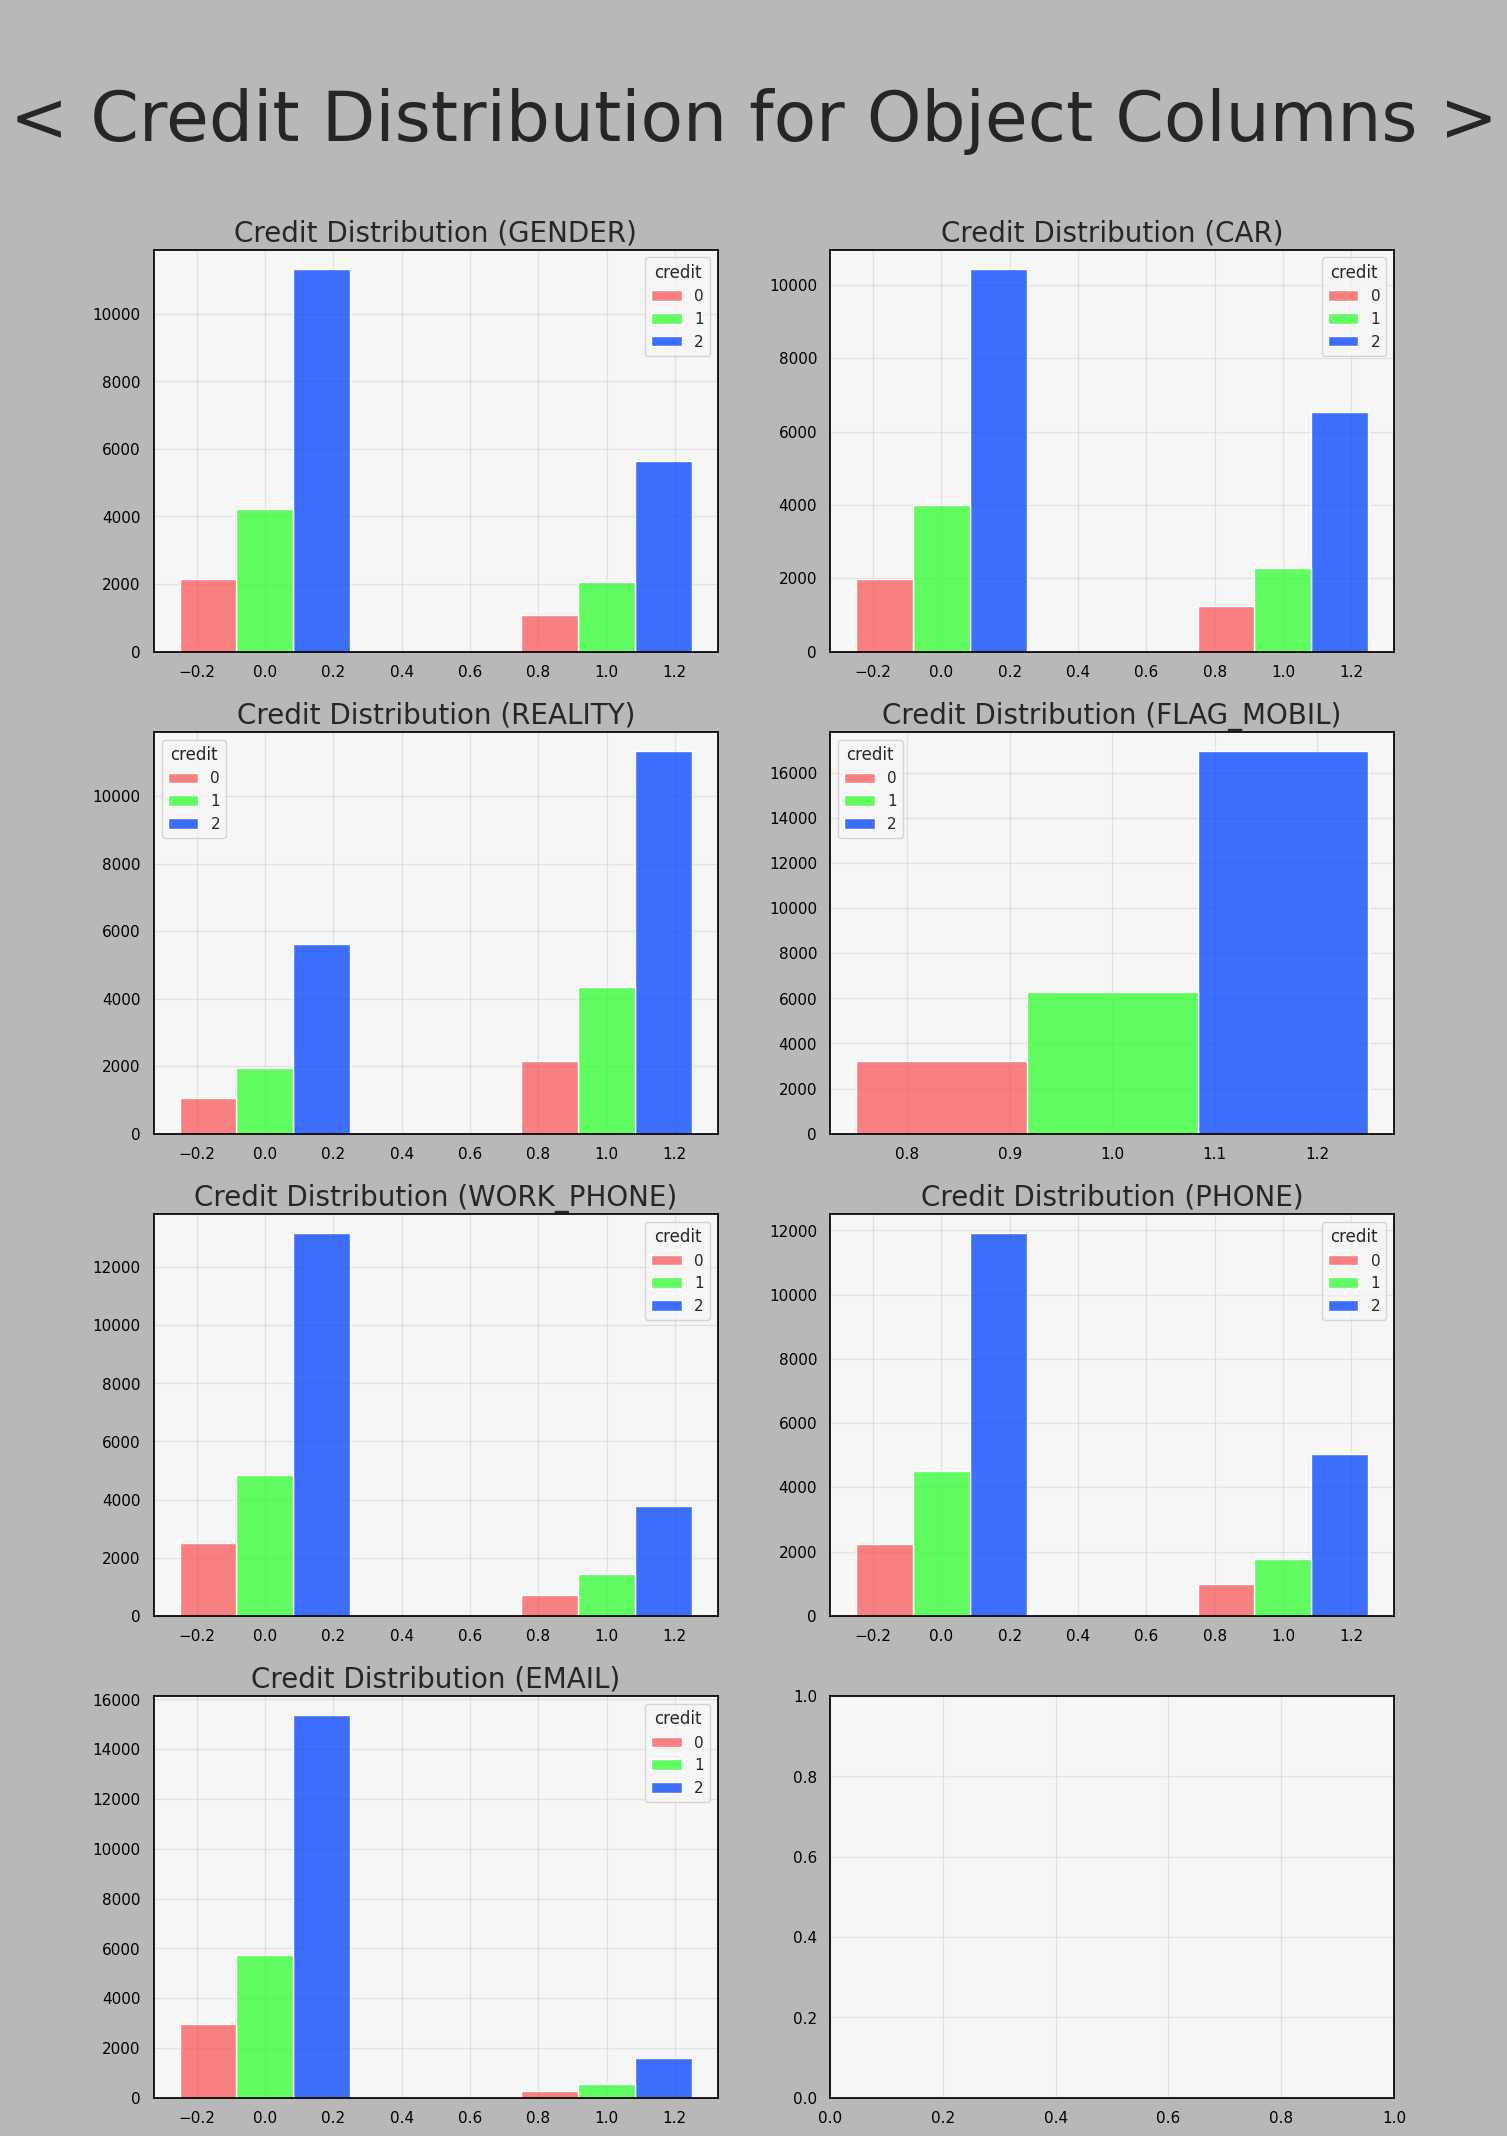

In [36]:
# binary category columns EDA
cat_EDA_cols = train_cat_bin.columns[:-1]
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_EDA_cols):
    ax = axes[i]
    sns.histplot(data=train_cat_bin, x=col, hue="credit",
                 binwidth=0.5, shrink=0.5,
                 palette=color, ax=ax,
                 multiple="dodge", hue_order=[0, 1, 2])
    ax.set_title(f"Credit Distribution ({col.upper()})", fontsize=20)
    ax.set_ylabel("")
    ax.set_xlabel("")

plt.suptitle("\n< Credit Distribution for Object Columns >", fontsize=50)
plt.show()


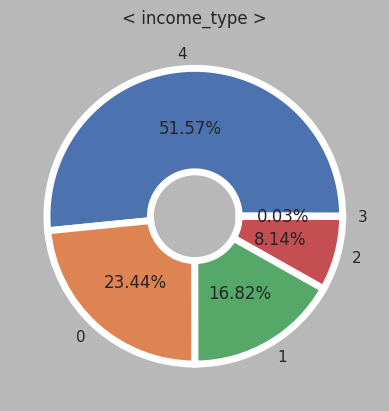

In [37]:
# 시각화는 다 plotly 로 심플하게 실습
ratio = train_cat_over["income_type"].value_counts()
labels = train_cat_over["income_type"].unique().categories
wedgeprops = {'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
plt.title("< income_type >")
plt.pie(x=ratio, labels=labels, autopct="%.2f%%", wedgeprops=wedgeprops)
plt.show()


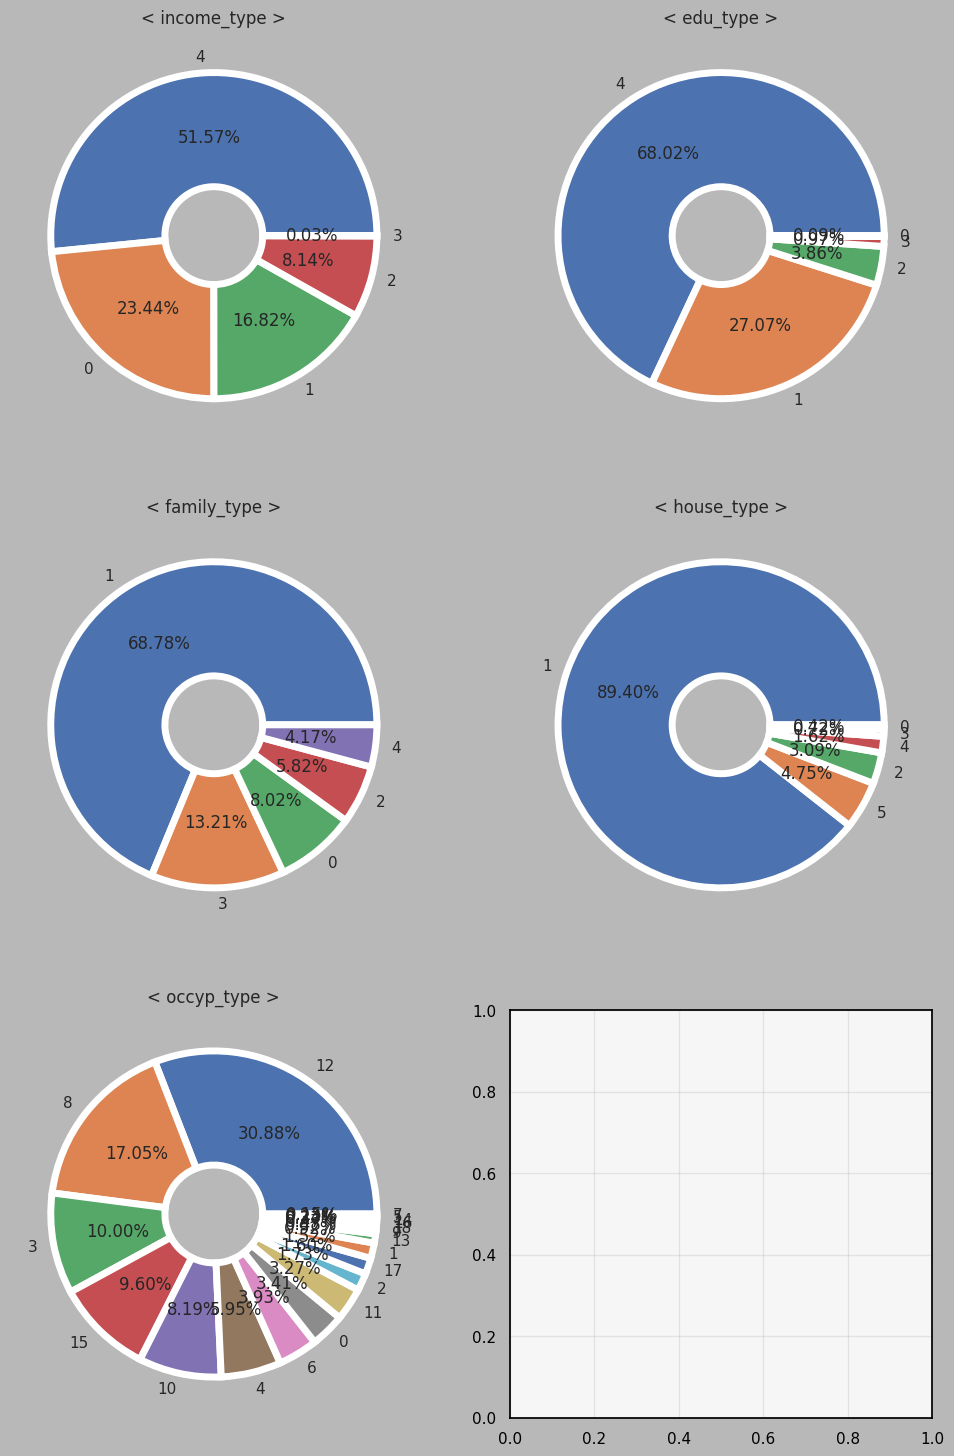

In [38]:
fig, axes = plt.subplots(3, 2, figsize=(12, 18))
axes = axes.flatten()
columns = train_cat_over.columns[:-1]

for i, col in enumerate(columns):
    ratio  = train_cat_over[col].value_counts()
    labels = train_cat_over[col].unique().categories
    wedgeprops = {'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
    axes[i].set_title(f"< {col} >")
    axes[i].pie(x=ratio, labels=labels, autopct="%.2f%%", wedgeprops=wedgeprops)

plt.show()


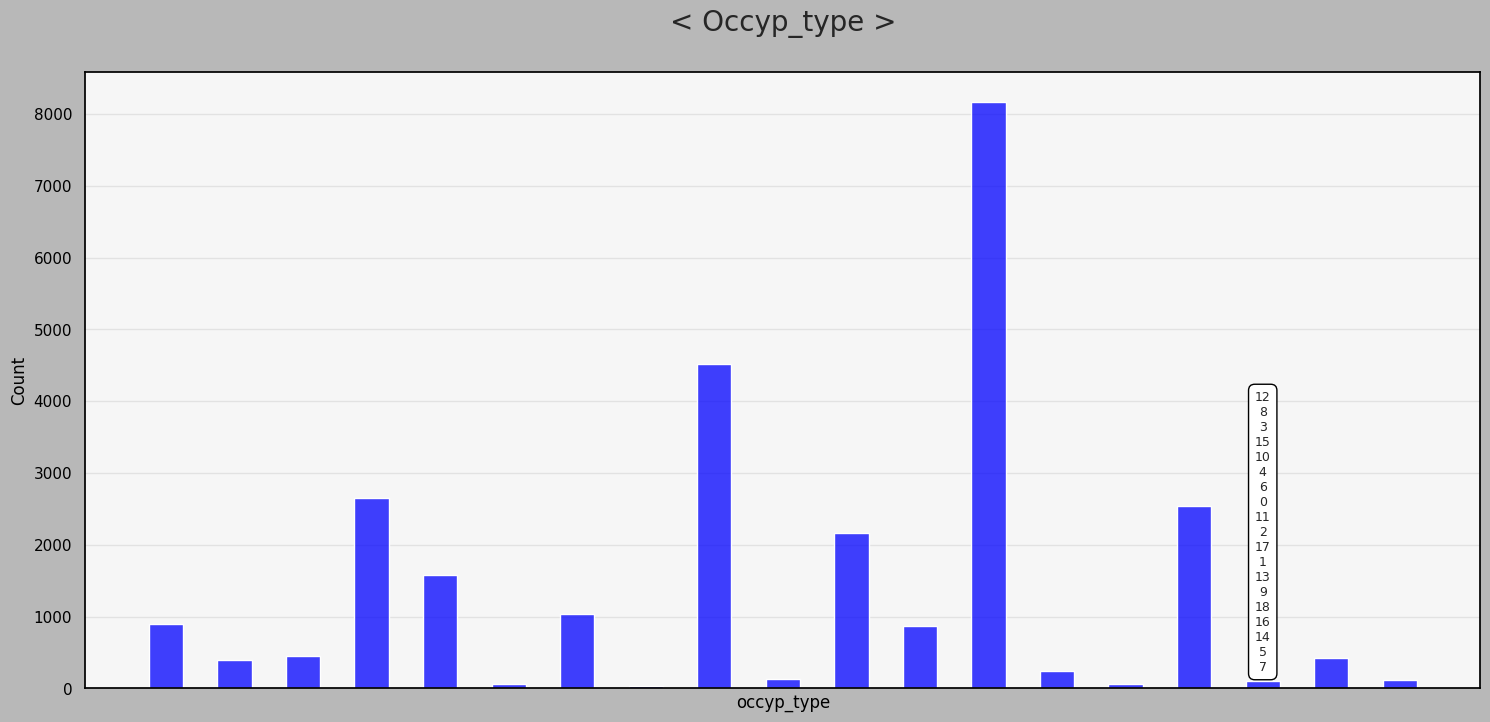

In [39]:
plt.figure(figsize=(18, 8))
sns.histplot(data=train_cat_over, x="occyp_type",
             binwidth=0.5, shrink=0.5, color="blue")
plt.xticks([])
plt.text(x=len(sorted_col) / 2 + 6.5, y=250,
         s='\n'.join(sorted_col.astype(str)),
         fontsize=9, ha='center',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
plt.title("< Occyp_type >", pad=30, fontsize=20)
plt.show()


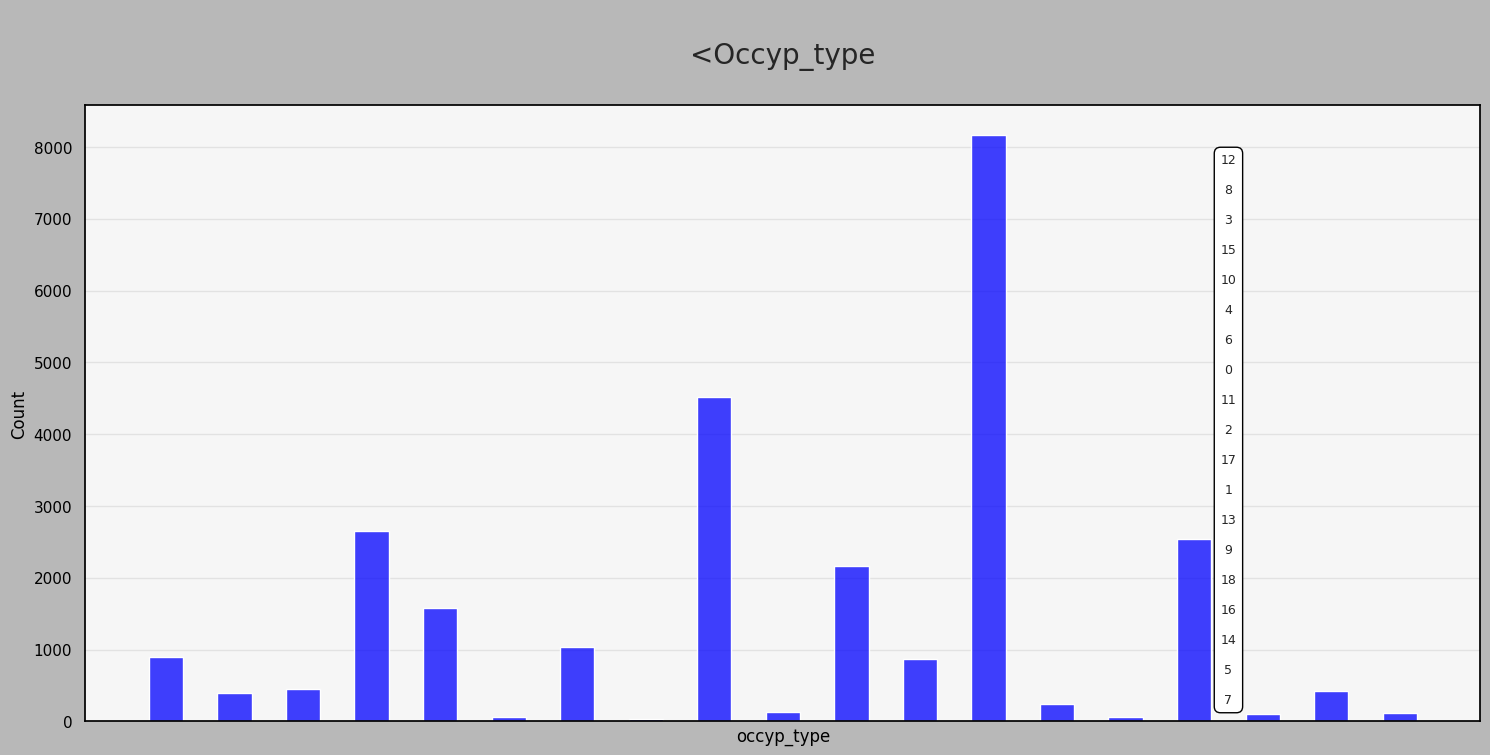

In [40]:
plt.figure(figsize=(18, 8))
sns.histplot(data=train_cat_over, x="occyp_type", binwidth=0.5, shrink=0.5, color="blue")
plt.xticks([])
plt.text(x=len(sorted_col) // 2 + 6.5, y=250,
         s='\n\n'.join(sorted_col.astype(str)), fontsize=9,
         ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
plt.title('\n<Occyp_type', pad=30, fontsize=20)
plt.show()


In [41]:
print(train['occyp_type'].head())


0    12
1     8
2    10
3    15
4    10
Name: occyp_type, dtype: object


In [42]:
# tabulate 모듈을 설치합니다
# 표형태로 나오는, 공식문서참조
!pip install tabulate
from tabulate import tabulate

output_table = []
occypys = train_cat_over['occyp_type'].value_counts().index
dfs = [train_cat_over[train_cat_over['occyp_type'] == occypys[i]]
       for i in range(len(occypys))]

for i, df in enumerate(dfs):
    output_table.append(
        [occypys[i],
         f"{round(len(df) / len(train_cat_over) * 100, 2)}%",
         round(df['credit'].value_counts(normalize=True) * 100, 2).astype("str") + "%"]
    )

print(tabulate(output_table,
               headers=['Occyp Type', 'Proportion', 'Credit Distribution'],
               tablefmt='grid'))


+--------------+--------------+---------------------------------+
|   Occyp Type | Proportion   | Credit Distribution             |
+==============+==============+=================================+
|           12 | 30.88%       | credit                          |
|              |              | 2.0    64.45%                   |
|              |              | 1.0    23.72%                   |
|              |              | 0.0    11.83%                   |
|              |              | Name: proportion, dtype: object |
+--------------+--------------+---------------------------------+
|            8 | 17.05%       | credit                          |
|              |              | 2.0    63.03%                   |
|              |              | 1.0    23.98%                   |
|              |              | 0.0    12.99%                   |
|              |              | Name: proportion, dtype: object |
+--------------+--------------+---------------------------------+
|         

### 피처 엔지니어링 (원본을 그대로 쓰는게 맞는지) good fit 에 맞추기 위해

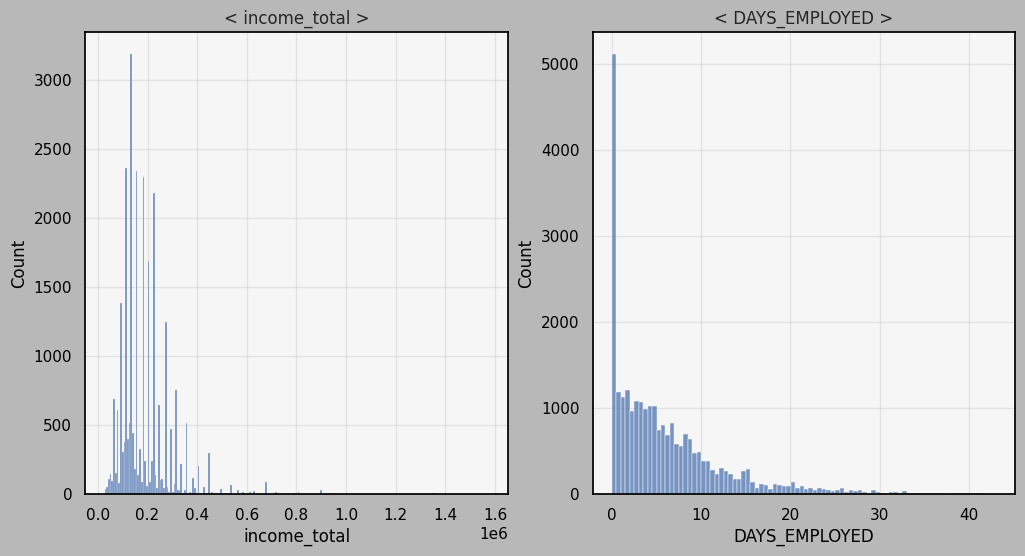

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# income_total, DAYS_EMPLOYED 변수의 히스토그램을 그립니다
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()
columns = ["income_total", "DAYS_EMPLOYED"]

for i, col in enumerate(columns):
    sns.histplot(data=train, x=col, ax=axes[i])
    axes[i].set_title(f"< {col} >")

plt.show()
# 스큐니스 0


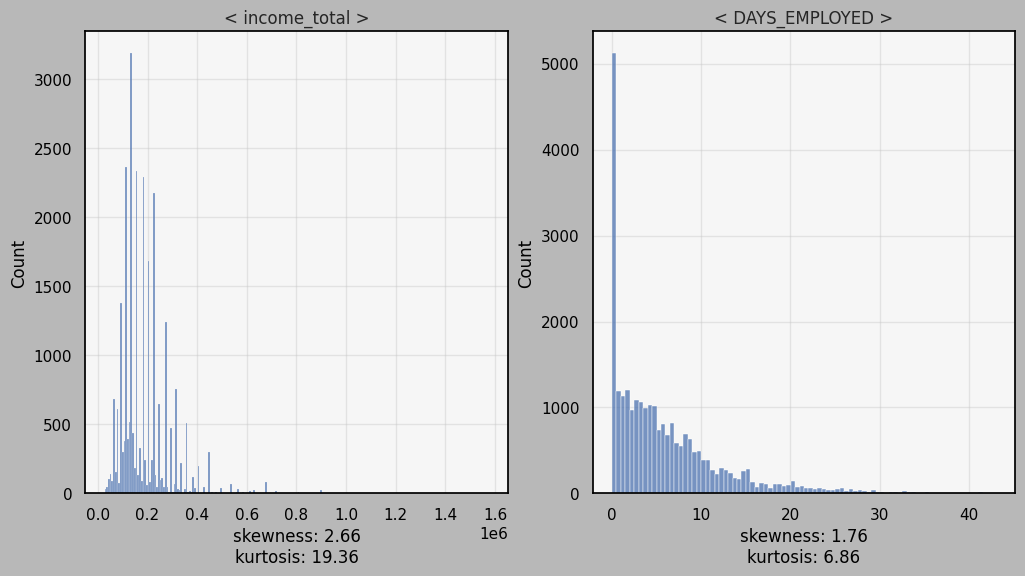

In [44]:
# kurtosis 값 확인, 산포도 ~3 에 가까워지면 노말
# ~3보다 작으면 얇다
# 크면 정규분포보다 두껍게

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()
columns = ["income_total", "DAYS_EMPLOYED"]

for i, col in enumerate(columns):
    sns.histplot(data=train, x=col, ax=axes[i])
    axes[i].set_title(f"< {col} >")
    skewness = skew(train[col])
    kurto    = kurtosis(train[col], fisher=False)
    axes[i].set_xlabel(
        f"skewness: {round(skewness, 2)}\nkurtosis: {round(kurto, 2)}"
    )

plt.show()


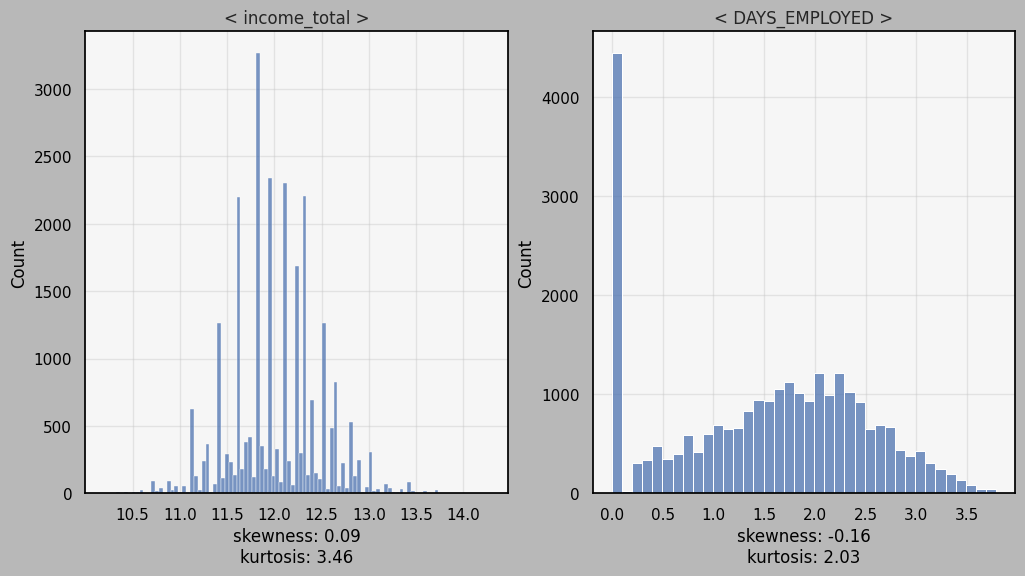

In [45]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()
columns = ["income_total", "DAYS_EMPLOYED"]

# 로그 변환 정규화
for i, col in enumerate(columns):
    if i == 1:
        data = np.log(train[col] + 1)
    else:
        data = np.log(train[col])
    sns.histplot(data=data, ax=axes[i])
    axes[i].set_title(f"< {col} >")
    skewness = skew(data)
    kurto    = kurtosis(data, fisher=False)
    axes[i].set_xlabel(
        f"skewness: {round(skewness, 2)}\nkurtosis: {round(kurto, 2)}"
    )

plt.show()


In [46]:
# test 데이터 로그 변환
test["income_total"]  = np.log(test["income_total"])
test["DAYS_EMPLOYED"] = np.log(test["DAYS_EMPLOYED"] + 1)

# train 데이터도 로그 변환
train["income_total"]  = np.log(train["income_total"])
train["DAYS_EMPLOYED"] = np.log(train["DAYS_EMPLOYED"] + 1)


In [47]:
# test 데이터에 "child_num_over_five" / 자식 5명 이상 자녀
test["child_num_over_five"]  = (test["child_num"]  > 5).astype(int)
train["child_num_over_five"] = (train["child_num"] > 5).astype(int)


In [48]:
# train 중복 행 확인
train.drop(columns="begin_month").duplicated().sum()


np.int64(0)

In [49]:
# test 중복 행 확인
test.drop(columns="begin_month").duplicated().sum()


np.int64(0)

In [50]:
# 신용카드 중복 개수 duplicated_num 변수 추가
train_drop = train.drop(columns="begin_month")
duplicated_num = train_drop.groupby(
    train_drop.columns.tolist(),
    as_index=False
).transform("size")
train["duplicated_num"] = duplicated_num
train.head()


,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,...,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit,child_num_over_five,duplicated_num
0,0,0,0,0,0,12.218495,0,1,1,2,...,1,0,0,0,12,2.0,6.0,1.0,0,1
1,1,0,0,1,1,12.419166,0,4,0,1,...,1,0,0,1,8,3.0,5.0,1.0,0,1
2,2,1,1,1,0,13.017003,4,1,1,1,...,1,0,1,0,10,2.0,22.0,2.0,0,1
3,3,0,0,1,0,12.218495,0,4,1,1,...,1,0,1,0,15,2.0,37.0,0.0,0,1
4,4,0,1,1,0,11.967181,2,1,1,1,...,1,0,0,0,10,2.0,26.0,2.0,0,1


In [51]:
test_drop = test.drop(columns="begin_month")
duplicated_num = test_drop.groupby(
    test_drop.columns.tolist(),
    as_index=False
).transform("size")
test["duplicated_num"] = duplicated_num


In [52]:
# before_employed 변수 추가
train["before_employed"] = train["DAYS_BIRTH"] - train["DAYS_EMPLOYED"]
test["before_employed"]  = test["DAYS_BIRTH"]  - test["DAYS_EMPLOYED"]


In [53]:
from tabulate import tabulate

output_table = []
types = train["house_type"].value_counts().index
dfs   = [train[train["house_type"] == types[i]] for i in range(len(types))]

for i, df in enumerate(dfs):
    output_table.append(
        [types[i],
         f"{round(len(df)/len(train)*100, 2)}%",
         round(df["credit"].value_counts(normalize=True)*100, 2).astype("str") + "%"]
    )

print(tabulate(
    output_table,
    headers=["House Type", "Proportion", "Credit Distribution"],
    tablefmt="grid"
))


+--------------+--------------+---------------------------------+
|   House Type | Proportion   | Credit Distribution             |
+==============+==============+=================================+
|            1 | 89.4%        | credit                          |
|              |              | 2.0    64.31%                   |
|              |              | 1.0    23.54%                   |
|              |              | 0.0    12.15%                   |
|              |              | Name: proportion, dtype: object |
+--------------+--------------+---------------------------------+
|            5 | 4.75%        | credit                          |
|              |              | 2.0    63.09%                   |
|              |              | 1.0     24.9%                   |
|              |              | 0.0    12.01%                   |
|              |              | Name: proportion, dtype: object |
+--------------+--------------+---------------------------------+
|         

In [54]:
# house_owner 집주인이냐 아니냐
train["house_owner"] = (train["house_type"] != "Rented apartment").astype(int)
test["house_owner"]  = (test["house_type"]  != "Rented apartment").astype(int)


In [55]:
# 레이블 인코딩 방법 vs one hot encoding (많을수록 차원이 늘어남.)

from sklearn.preprocessing import LabelEncoder

cols = train.select_dtypes(include=["object"]).columns
le   = LabelEncoder()

for col in cols:
    le.fit(train[col])
    train[col] = le.transform(train[col])
    test[col]  = test[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
    test[col]  = le.transform(test[col])

# 저장
train.to_csv("train_processed.csv", index=False)
test.to_csv("test_processed.csv",   index=False)


### 하이퍼 파라미터 튜닝 및 최종 모델링

In [56]:
train      = pd.read_csv("train_processed.csv")
test       = pd.read_csv("test_processed.csv")
submission = pd.read_csv("sample_submission.csv")

print(train["credit"].value_counts())

# 앙상블 모델 보팅. 투표 > 다수결(하드보팅) 소프트 보팅(평균)
# 배깅 > 병렬 수행 (부트스트랩 모델) 랜덤포레스트 알고리즘 parallel
# 부스팅 (강화해나가는 방법)


credit
2.0    16968
1.0     6267
0.0     3222
Name: count, dtype: int64


In [57]:
X = train.drop(columns="credit")
y = train["credit"]

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)


In [58]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [59]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    recall_score, precision_score,
    f1_score, log_loss
)

pred_1 = dt.predict(X_valid)

valid_cm_1        = confusion_matrix(y_valid, pred_1)
valid_acc_1       = accuracy_score(y_valid, pred_1)
valid_recall_1    = recall_score(y_valid, pred_1, average="weighted")
valid_precision_1 = precision_score(y_valid, pred_1, average="weighted")
valid_f1_1        = f1_score(y_valid, pred_1, average="weighted")

print("Confusion Matrix(혼동행렬):\n", valid_cm_1)
print()
print("Accuracy(정확도):",  round(valid_acc_1*100, 2))
print("Recall(재현율):",    round(valid_recall_1*100, 2))
print("Precision(정밀도):", round(valid_precision_1*100, 2))
print("F1 Score:",          round(valid_f1_1, 4))


Confusion Matrix(혼동행렬):
 [[ 170  157  317]
 [ 155  565  534]
 [ 378  565 2451]]

Accuracy(정확도): 60.2
Recall(재현율): 60.2
Precision(정밀도): 60.95
F1 Score: 0.6056


In [60]:
from sklearn.metrics import classification_report

# 지수가중 평균
# y_valid는 실제 레이블, pred_1은 모델 예측 결과
report = classification_report(y_valid, pred_1)
print(report)


              precision    recall  f1-score   support

         0.0       0.24      0.26      0.25       644
         1.0       0.44      0.45      0.44      1254
         2.0       0.74      0.72      0.73      3394

    accuracy                           0.60      5292
   macro avg       0.47      0.48      0.48      5292
weighted avg       0.61      0.60      0.61      5292



begin_month        0.238880
index              0.203680
before_employed    0.099982
DAYS_EMPLOYED      0.097413
DAYS_BIRTH         0.082862
income_total       0.078585
occyp_type         0.044104
family_type        0.022596
family_size        0.016613
phone              0.015458
income_type        0.015042
reality            0.014885
house_type         0.012167
car                0.011880
child_num          0.011384
gender             0.011056
edu_type           0.008500
work_phone         0.008126
email              0.006786
FLAG_MOBIL         0.000000
dtype: float64


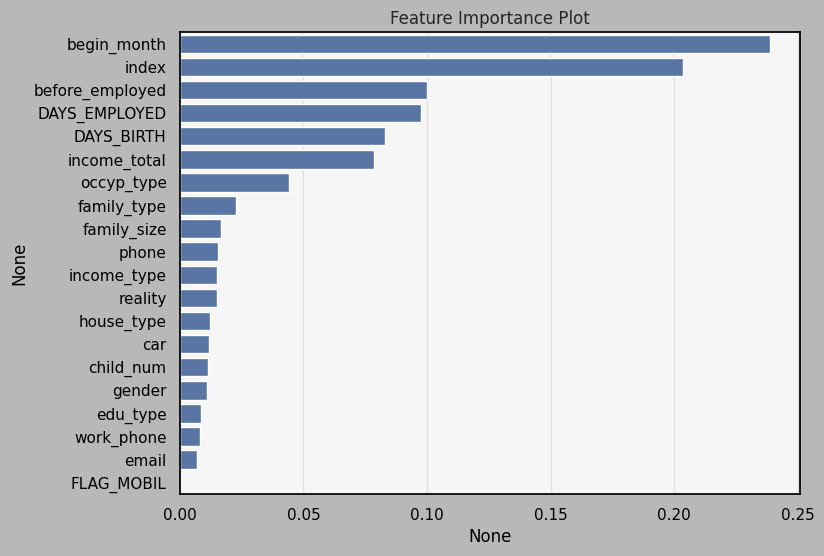

In [61]:
# 어떤 중요도를 가져오나
feature_importances = pd.Series(
    dt.feature_importances_,
    index=X_valid.columns
).sort_values(ascending=False)
feature_importance = feature_importances.head(20)
print(feature_importance)

# 시각화
%matplotlib inline
plt.figure(figsize=(8, 6))
plt.title("Feature Importance Plot")
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.show()


In [62]:
# 예측확률
prob_1     = dt.predict_proba(X_valid)
log_loss_1 = log_loss(y_valid, prob_1)
print("Log loss(로그 손실):", round(log_loss_1, 4))


Log loss(로그 손실): 14.3439


In [63]:
# 랜덤포레스트
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

# 학습
rf.fit(X_train, y_train)

# 예측
pred_2 = rf.predict(X_valid)

# 정확도 평가
accuracy = accuracy_score(y_valid, pred_2)
print(f"RandomForestClassifier 정확도: {accuracy:.4f}")

# 오차행렬
cm2 = confusion_matrix(y_valid, pred_2)
print(cm2)


RandomForestClassifier 정확도: 0.7188
[[ 132  113  399]
 [  38  535  681]
 [  91  166 3137]]


In [64]:
pred_2 = rf.predict(X_valid)

valid_cm_2        = confusion_matrix(y_valid, pred_2)
valid_acc_2       = accuracy_score(y_valid, pred_2)
valid_recall_2    = recall_score(y_valid, pred_2, average="weighted")
valid_precision_2 = precision_score(y_valid, pred_2, average="weighted")
valid_f1_2        = f1_score(y_valid, pred_2, average="weighted")

print("Confusion Matrix(혼동행렬):\n", valid_cm_2)
print()
print("Accuracy(정확도):",  round(valid_acc_2*100, 2))
print("Recall(재현율):",    round(valid_recall_2*100, 2))
print("Precision(정밀도):", round(valid_precision_2*100, 2))
print("F1 Score:",          round(valid_f1_2, 4))


Confusion Matrix(혼동행렬):
 [[ 132  113  399]
 [  38  535  681]
 [  91  166 3137]]

Accuracy(정확도): 71.88
Recall(재현율): 71.88
Precision(정밀도): 69.44
F1 Score: 0.6868


In [65]:
# 변수 중요도 계산
importances_values = pd.Series(
    rf.feature_importances_,
    index=X_valid.columns
).sort_values(ascending=False)
rf_top20 = importances_values.head(20)
rf_top20


,0
begin_month,0.227521
index,0.169018
before_employed,0.102042
DAYS_BIRTH,0.100302
DAYS_EMPLOYED,0.083279
income_total,0.082444
occyp_type,0.048028
family_type,0.021614
family_size,0.019568
income_type,0.018684


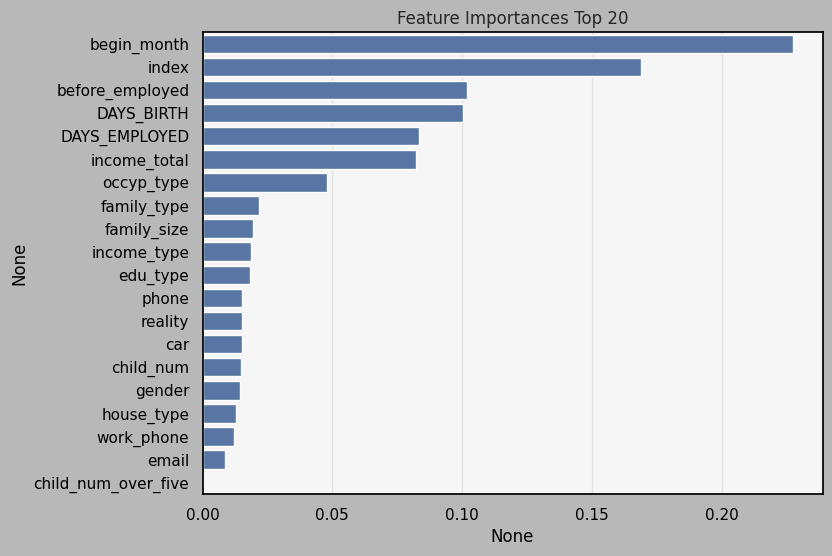

In [66]:
plt.figure(figsize=(8, 6))
plt.title("Feature Importances Top 20")
sns.barplot(x=rf_top20, y=rf_top20.index)
plt.show()
# 로그 로스값 뽑아보기 (배깅을 써 줄어듬 확인)


In [67]:
# xgboost 사용
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)  # verbose=1

# 학습
xgb.fit(X_train, y_train)

# 예측
pred_3 = xgb.predict(X_valid)

# 정확도
accuracy = accuracy_score(y_valid, pred_3)
print(f"XGBoost 정확도: {accuracy:.4f}")

# 혼동행렬
cm3 = confusion_matrix(y_valid, pred_3)
print(cm3)


XGBoost 정확도: 0.7060
[[  57   92  495]
 [  23  378  853]
 [  22   71 3301]]


In [68]:
pred_3 = xgb.predict(X_valid)

valid_cm_3        = confusion_matrix(y_valid, pred_3)
valid_acc_3       = accuracy_score(y_valid, pred_3)
valid_recall_3    = recall_score(y_valid, pred_3, average="weighted")
valid_precision_3 = precision_score(y_valid, pred_3, average="weighted")
valid_f1_3        = f1_score(y_valid, pred_3, average="weighted")

print("Confusion Matrix(혼동행렬):\n", valid_cm_3)
print()
print("Accuracy(정확도):",  round(valid_acc_3*100, 2))
print("Recall(재현율):",    round(valid_recall_3*100, 2))
print("Precision(정밀도):", round(valid_precision_3*100, 2))
print("F1 Score:",          round(valid_f1_3, 4))


Confusion Matrix(혼동행렬):
 [[  57   92  495]
 [  23  378  853]
 [  22   71 3301]]

Accuracy(정확도): 70.6
Recall(재현율): 70.6
Precision(정밀도): 68.9
F1 Score: 0.6448


In [69]:
# 제출 파일 생성 (RandomForest 기준)
pred_test = rf.predict_proba(test)
submission = submission.astype(float)
submission.iloc[:, 1:] = pred_test
submission.to_csv("submission_rf.csv", index=False)
print("제출 파일 저장 완료: submission_rf.csv")
submission.head()


제출 파일 저장 완료: submission_rf.csv


,index,0,1,2
0,26457.0,0.09,0.28,0.63
1,26458.0,0.07,0.23,0.70
2,26459.0,0.14,0.25,0.61
3,26460.0,0.19,0.16,0.65
4,26461.0,0.10,0.29,0.61
